# Medical Insurance Cost Analysis and Prediction

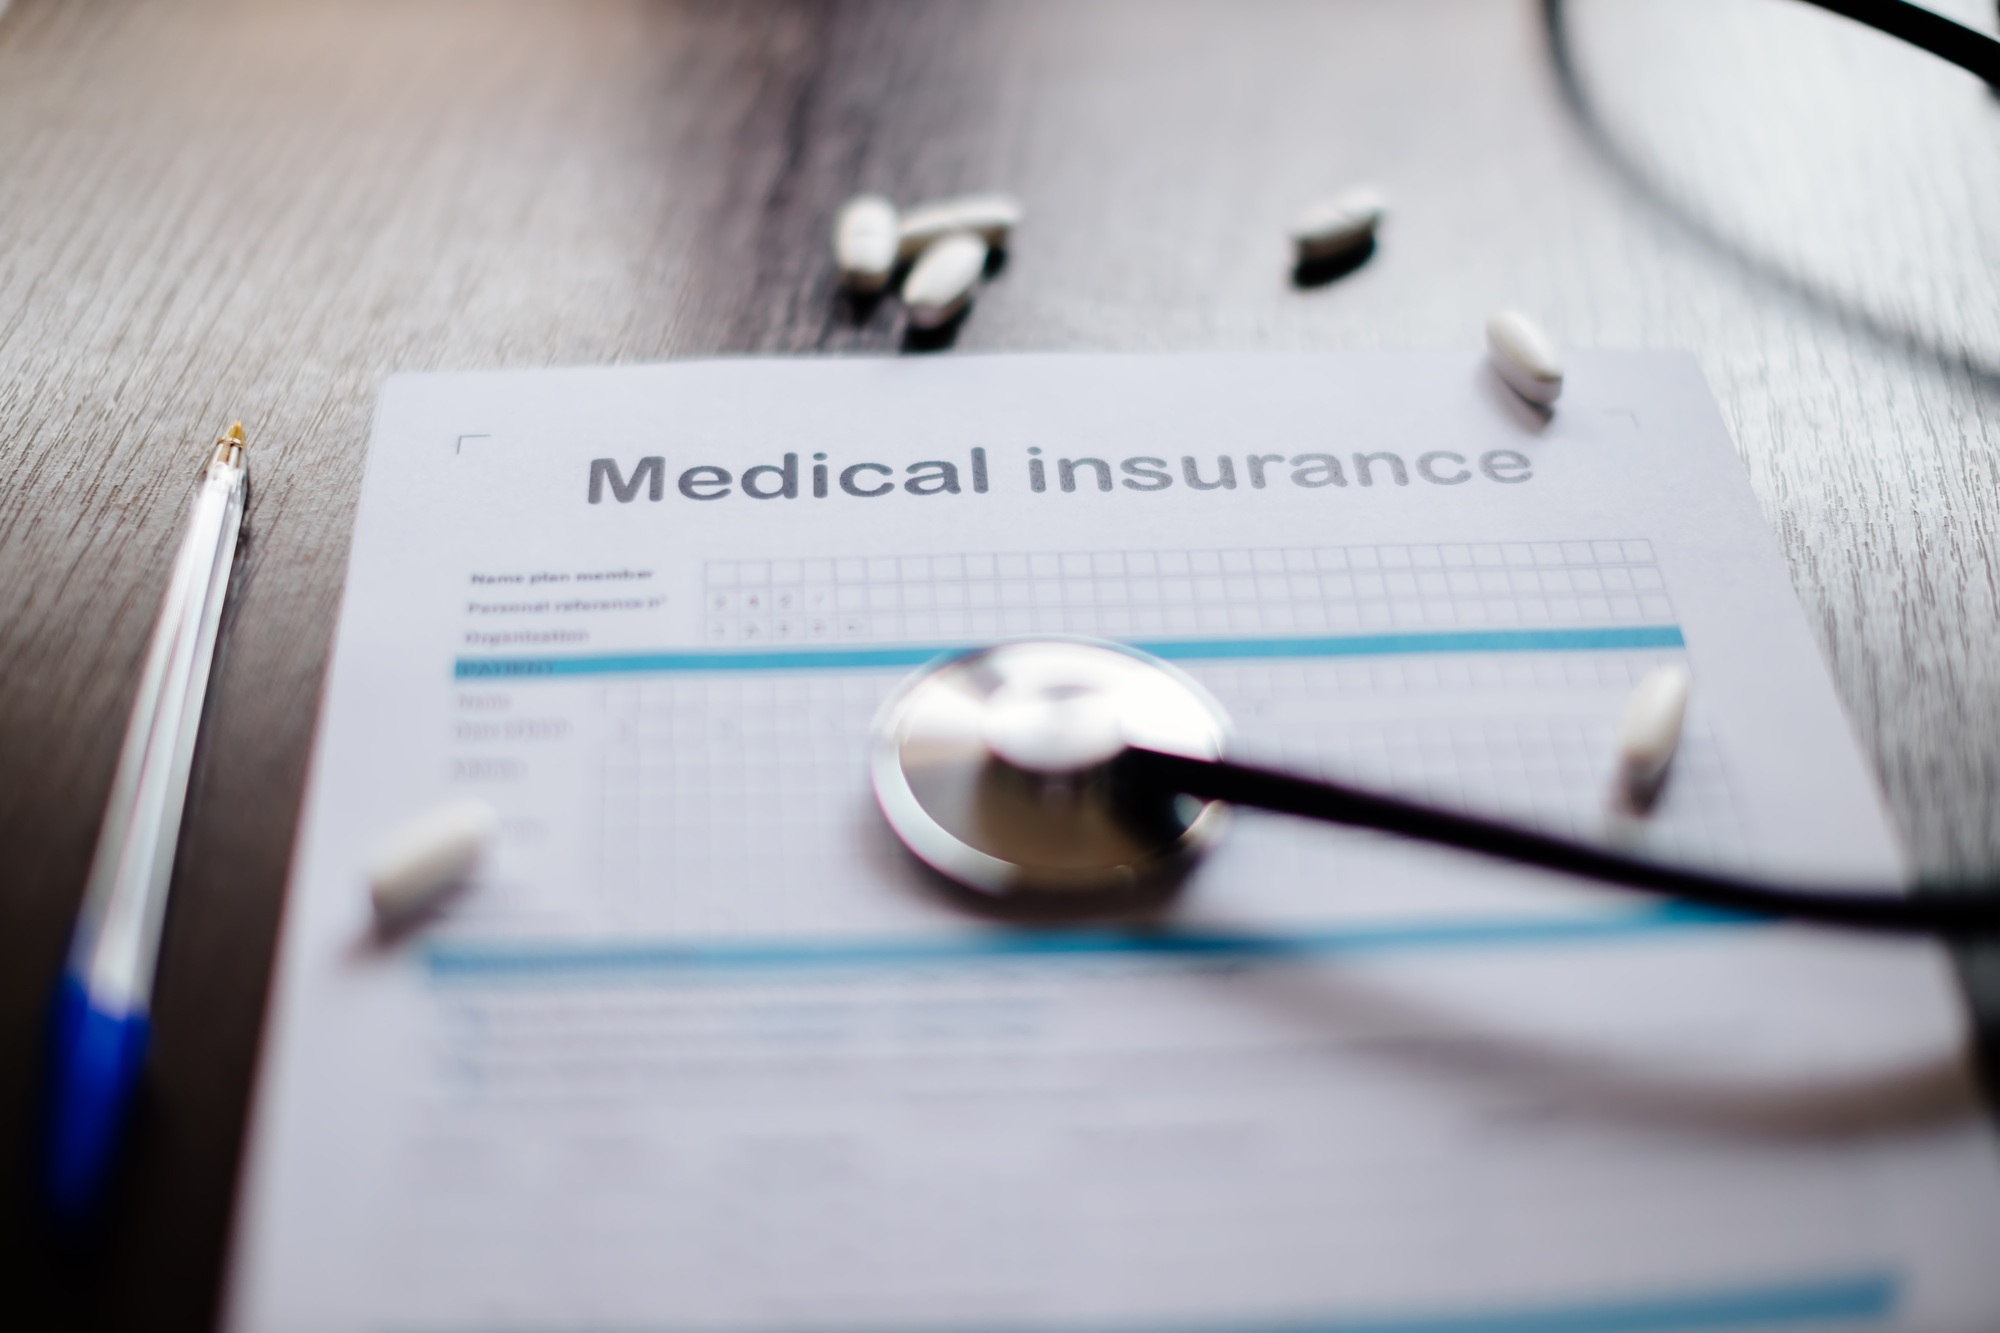

### 🔗 Modeling Overview

This notebook builds upon insights derived from the exploratory data analysis (EDA) conducted in the previous notebook.

Key findings from EDA included:

- Medical charges are highly right-skewed.

- Strong nonlinear relationships exist between age and charges.

- Significant interaction effects were observed between smoking status and BMI, as well as smoking status and age.

- Variance increases with age and smoking status.

- Region and gender contribute minimally to charge variation.

Based on these insights, the modeling strategy focuses on:

- Applying log transformation to stabilize the target variable.

- Engineering nonlinear and interaction features.

- Comparing linear and ensemble-based models.

- Performing hyperparameter tuning to optimize performance.

The objective of this notebook is to identify the best-performing predictive model for estimating medical insurance charges while maintaining interpretability and generalization performance.

### Importing dependencies and Data Handling

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [11]:
# import data
data = pd.read_csv('cleaned_insurance_data.csv')
data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Data Preprocessing and Feature Engineering

In [12]:
df = data.copy()
# mapping sex and smoker to binary values
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# One-hot encoding 
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Applying log transformation on target feature charges
df['log_charges'] = np.log1p(df['charges'])

# Creating interaction variables from the features
df['age_smoker'] = df['age'] * df['smoker']
df['bmi_smoker'] = df['bmi'] * df['smoker']

# Polynomial age term for linear regression to capture nonlinear aging effect
df['age_squared'] = df['age'] ** 2

# Obesity risk flag since obesity jumps cost
df['is_obese'] = (df['bmi'] >= 30).astype(int)

df.head()



,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,log_charges,age_smoker,bmi_smoker,age_squared,is_obese
0,19,1,27.900,0,1,16884.92400,False,False,True,9.734236,19,27.9,361,0
1,18,0,33.770,1,0,1725.55230,False,True,False,7.453882,0,0.0,324,1
2,28,0,33.000,3,0,4449.46200,False,True,False,8.400763,0,0.0,784,1
3,33,0,22.705,0,0,21984.47061,True,False,False,9.998137,0,0.0,1089,0
4,32,0,28.880,0,0,3866.85520,True,False,False,8.260455,0,0.0,1024,0


### Model Build

##### - Linear Regression using non-engineered features

In [13]:
# Train-test-split
from sklearn.model_selection import train_test_split
X = df.drop(['charges', 'log_charges', 'age_smoker', 'bmi_smoker', 'age_squared', 'is_obese'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'shape of the predictive variables: {X_train.shape, X_test.shape}')
print(f'shape of the target variable: {y_train.shape, y_test.shape}') 

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

shape of the predictive variables: ((1069, 8), (268, 8))
shape of the target variable: ((1069,), (268,))


##### - Linear Regression using engineered features

In [14]:
# Train-test-split
X_elr = df.drop(['charges', 'log_charges'], axis=1)
y_elr = df['log_charges']
X_elr_train, X_elr_test, y_elr_train, y_elr_test = train_test_split(X_elr, y_elr, random_state=42, test_size=0.2)

lr_e = LinearRegression()
lr_e.fit(X_elr_train, y_elr_train)
lr_e_pred = lr_e.predict(X_elr_test)

# converting log predictions back to original scale
lr_e_pred_exp = np.expm1(lr_e_pred)
y_elr_test_exp = np.expm1(y_elr_test)

##### - RandomForest using non-engineered features

In [15]:
# Train-test-split
X_rf = df.drop(['charges', 'log_charges', 'age_smoker', 'bmi_smoker', 'age_squared', 'is_obese'], axis=1)
y_rf = df['charges']
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, random_state=42, test_size=0.2)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_rf_train, y_rf_train)
rf_pred = rf.predict(X_rf_test)

##### - RandomForest using engineered features

In [16]:
# Train-test-split
X_erf = df.drop(['charges', 'log_charges'], axis=1)
y_erf = df['log_charges']
X_erf_train, X_erf_test, y_erf_train, y_erf_test = train_test_split(X_erf, y_erf, test_size=0.2, random_state=42)

rf_e = RandomForestRegressor()
rf_e.fit(X_erf_train, y_erf_train)
rf_e_pred = rf_e.predict(X_erf_test)

# converting log predictions back to original scale
rf_e_pred_exp = np.expm1(rf_e_pred)
y_erf_test_exp = np.expm1(y_erf_test)

##### - XGBoost

In [17]:
# Train-test-split
X_xgb = df.drop(['charges', 'log_charges'], axis=1)
y_xgb = df['log_charges']

X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_xgb, y_xgb, random_state=42, test_size=0.2)

from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_xgb_train, y_xgb_train)
xgb_pred = xgb.predict(X_xgb_test)

# converting log predictions back to original scale
xgb_pred_exp = np.expm1(xgb_pred)
y_xgb_test_exp = np.expm1(y_xgb_test)

### Evaluation

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Linear Regression without engineered features
r2_lr = r2_score(y_test, lr_pred)
mae_lr = mean_absolute_error(y_test, lr_pred)
mse_lr = mean_squared_error(y_test, lr_pred)
print('R2_LinearRegression:', r2_lr)
print('MAE_LinearRegression:', mae_lr)
print('MSE_LinearRegression:', mse_lr)

# Linear Reegression with engineered features
r2_e_lr = r2_score(y_elr_test_exp, lr_e_pred_exp)
mae_e_lr = mean_absolute_error(y_elr_test_exp, lr_e_pred_exp)
mse_e_lr = mean_squared_error(y_elr_test_exp, lr_e_pred_exp)
print('\nR2_Engineered_LinearRegression:', r2_e_lr)
print('MAE_Engineered_LinearRegression:', mae_e_lr)
print('MSE_Engineered_LinearRegression:', mse_e_lr)

# RandomForest without engineered features
r2_rf = r2_score(y_rf_test, rf_pred)
mae_rf = mean_absolute_error(y_rf_test, rf_pred)
mse_rf = mean_squared_error(y_rf_test, rf_pred)
print('\nR2_RandomForest:', r2_rf)
print('MAE_RandomForest:', mae_rf)
print('MSE_RandomForest:', mse_rf)

# RandomForest with engineered features
r2_e_rf = r2_score(y_erf_test_exp, rf_e_pred_exp)
mae_e_rf = mean_absolute_error(y_erf_test_exp, rf_e_pred_exp)
mse_e_rf = mean_squared_error(y_erf_test_exp, rf_e_pred_exp)
print('\nR2_Engineered_RandomForest:', r2_e_rf)
print('MAE_Engineered_RandomForest:', mae_e_rf)
print('MSE_Engineered_RandomForest:', mse_e_rf)

# XGBoost
r2_xgb = r2_score(y_xgb_test_exp, xgb_pred_exp)
mae_xgb = mean_absolute_error(y_xgb_test_exp, xgb_pred_exp)
mse_xgb = mean_squared_error(y_xgb_test_exp, xgb_pred_exp)
print('\nR2_XGBoost:', r2_xgb)
print('MAE_XGBoost:', mae_xgb)
print('MSE_XGBoost:', mse_xgb)

R2_LinearRegression: 0.8069287081198013
MAE_LinearRegression: 4177.045561036318
MSE_LinearRegression: 35478020.67523558

R2_Engineered_LinearRegression: 0.8243791236716859
MAE_Engineered_LinearRegression: 2955.588372610783
MSE_Engineered_LinearRegression: 32271400.997539677

R2_RandomForest: 0.8813103773043132
MAE_RandomForest: 2647.5612682694027
MSE_RandomForest: 21809937.909082547

R2_Engineered_RandomForest: 0.8933865544980673
MAE_Engineered_RandomForest: 2083.3976566779347
MSE_Engineered_RandomForest: 19590867.11929541

R2_XGBoost: 0.8518376573076022
MAE_XGBoost: 2704.8163396831856
MSE_XGBoost: 27225728.93226356


### Hyperparameter Tuning

In [19]:
from sklearn.model_selection import RandomizedSearchCV
# Parameter Grid for RandomForest using engineered features
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 'None']
    }

rf_tuned = RandomForestRegressor(random_state=42)
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_erf_train, y_erf_train)
print('Best Hyperparameters for RandomForest:', rf_random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters for RandomForest: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 40}


In [21]:
best_rf = rf_random_search.best_estimator_
rf_tuned_pred = best_rf.predict(X_erf_test)

# converting log predictions back to original scale
rf_tuned_pred_exp = np.expm1(rf_tuned_pred)
y_erf_test_exp = np.expm1(y_erf_test)

# Evaluating tuned RandomForest
r2_rf_tuned = r2_score(y_erf_test_exp, rf_tuned_pred_exp)
mae_rf_tuned = mean_absolute_error(y_erf_test_exp, rf_tuned_pred_exp)
mse_rf_tuned = mean_squared_error(y_erf_test_exp, rf_tuned_pred_exp)
print(f'\nR2_Tuned_RandomForest: {r2_rf_tuned:.4f}')
print(f'MAE_Tuned_RandomForest: {mae_rf_tuned:.2f}')
print(f'MSE_Tuned_RandomForest: {mse_rf_tuned:.2f}')


R2_Tuned_RandomForest: 0.8983
MAE_Tuned_RandomForest: 1936.89
MSE_Tuned_RandomForest: 18695057.02


### Feature Importance

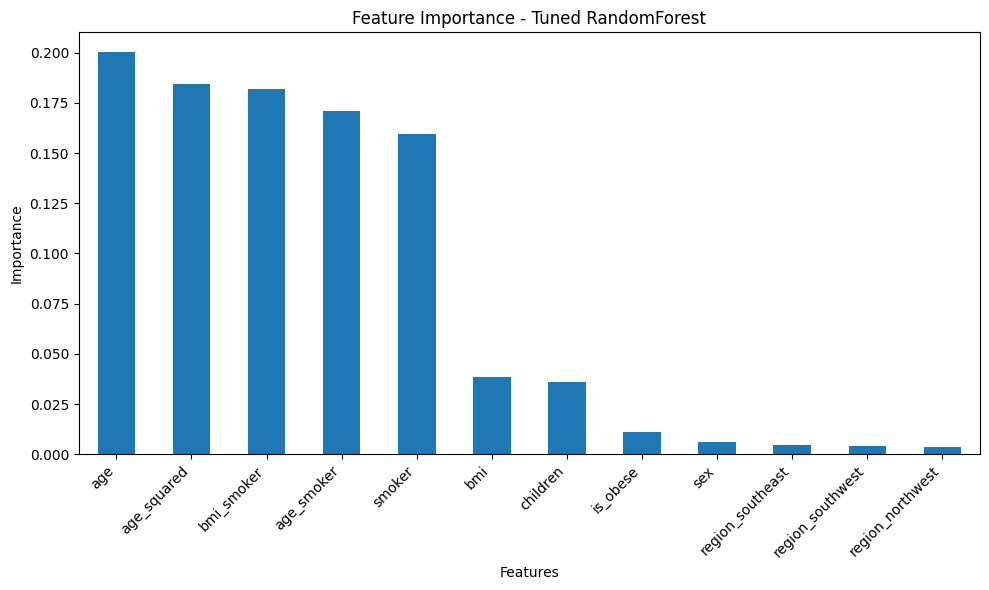

In [22]:
# Feature importance from the tuned RandomForest
feature_importances = pd.Series(best_rf.feature_importances_, index=X_erf_train.columns)
feature_importances.sort_values(ascending=False, inplace=True)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance - Tuned RandomForest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Saving

In [23]:
# save the model
import joblib
joblib.dump(best_rf, 'tuned_random_forest_model.pkl')

# Save the feature columns used in the model
joblib.dump(X_erf_train.columns.tolist(), 'model_features.pkl')


['model_features.pkl']

##### Modeling Results and Final Model Selection

Several regression models were evaluated to predict medical insurance charges using the engineered feature set. The objective was to identify the model that best captures the nonlinear relationships and interaction effects observed during exploratory data analysis.

A baseline Linear Regression model was first trained using the original features. This model achieved an R² score of approximately **0.807**, with a mean absolute error (MAE) of about **$4,177**, indicating that while the model captured some of the variability in insurance charges, it struggled to model more complex relationships in the data.

To improve performance, additional features were engineered based on patterns observed during EDA. These included nonlinear transformations and interaction terms such as `age_squared`, `age_smoker`, `bmi_smoker`, and an obesity indicator derived from BMI. Incorporating these features improved the Linear Regression model’s performance, increasing the R² score to **0.824** and reducing the MAE to approximately **$2,956**. This confirmed that the engineered features helped capture important nonlinear and interaction effects.

Tree-based ensemble models were then explored to better model the complex relationships present in the dataset. A Random Forest regressor significantly outperformed the linear models, achieving an R² score of **0.881** and reducing the MAE to approximately **$2,648**. The improvement demonstrates the ability of ensemble methods to automatically capture nonlinearities and feature interactions.

When the engineered features were incorporated into the Random Forest model, performance improved further. The engineered Random Forest achieved an R² score of **0.893** and reduced the MAE to approximately **$2,083**, making it the best-performing model prior to hyperparameter tuning.

To further optimize model performance, hyperparameter tuning was performed using randomized search with cross-validation. The tuned Random Forest model achieved the best overall performance, with an **R² score of approximately 0.898**, a **mean absolute error of about $1,937**, and an **RMSE of approximately $4,324**. This indicates that the model is able to explain nearly **90% of the variance in insurance charges**, while maintaining relatively low prediction error.

An additional XGBoost model was also evaluated, achieving an R² score of **0.852** with an MAE of approximately **$2,705**. Although XGBoost performed well, it did not outperform the tuned Random Forest model in this case.

Feature importance analysis from the final model revealed that **age**, **nonlinear age effects**, **smoking status**, and interaction features such as **BMI × smoker** and **age × smoker** are the most influential predictors of insurance charges. In contrast, demographic variables such as **sex** and **region** contributed relatively little to the model's predictions.

Overall, the tuned Random Forest model provided the best balance of predictive performance and interpretability. The results confirm that healthcare costs are strongly influenced by age-related factors, smoking behavior, and their interaction with body mass index.
